![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [3]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [4]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [5]:
# Celda 1
def calcular_mse_division(columna_feature, variable_objetivo, umbral):
    
    mascara_izquierda = columna_feature < umbral
    y_izquierda = variable_objetivo.loc[mascara_izquierda]
    y_derecha = variable_objetivo.loc[~mascara_izquierda]
    
    n_izquierda = y_izquierda.shape[0]
    n_derecha = y_derecha.shape[0]

    mse_izquierda = 0
    mse_derecha = 0
    
    if n_izquierda > 0:
        mse_izquierda = np.mean((y_izquierda - np.mean(y_izquierda)) ** 2)
    if n_derecha > 0:
        mse_derecha = np.mean((y_derecha - np.mean(y_derecha)) ** 2)
    
    total = n_izquierda + n_derecha
    
    mse_total = (n_izquierda / total) * mse_izquierda + \
                (n_derecha / total) * mse_derecha
    
    return mse_total


def encontrar_mejor_division(X_datos, y_datos, num_percentiles=10):
    
    num_variables = X_datos.shape[1]
    mejor_variable = None
    mejor_umbral = None
    mejor_mse = float("inf")
    
    for idx_variable in range(num_variables):
        
        percentiles = np.percentile(
            X_datos.iloc[:, idx_variable],
            np.linspace(0, 100, num_percentiles + 2)
        )
        
        posibles_umbral = np.unique(percentiles)[1:-1]
        
        for umbral in posibles_umbral:
            mse_actual = calcular_mse_division(
                X_datos.iloc[:, idx_variable], 
                y_datos, 
                umbral
            )
            
            if mse_actual < mejor_mse:
                mejor_variable = idx_variable
                mejor_umbral = umbral
                mejor_mse = mse_actual
    
    return mejor_variable, mejor_umbral, mejor_mse


def construir_arbol(X_datos, y_datos, profundidad=0, max_profundidad=3, min_mse=0):
    
    # Nodo hoja
    if X_datos.shape[0] <= 1:
        return {
            "prediccion": y_datos.iloc[0],
            "profundidad": profundidad,
            "split": None
        }
    
    variable, umbral, mse = encontrar_mejor_division(X_datos, y_datos)
    
    prediccion = y_datos.mean()
    
    nodo = {
        "prediccion": prediccion,
        "profundidad": profundidad,
        "split": None,
        "mse": mse,
        "n_muestras": X_datos.shape[0]
    }
    
    # Criterios de parada
    if mse <= min_mse or profundidad >= max_profundidad:
        return nodo
    
    # División
    mascara_izquierda = X_datos.iloc[:, variable] < umbral
    X_izquierda, y_izquierda = X_datos.loc[mascara_izquierda], y_datos.loc[mascara_izquierda]
    X_derecha, y_derecha = X_datos.loc[~mascara_izquierda], y_datos.loc[~mascara_izquierda]
    
    if len(X_izquierda) > 0 and len(X_derecha) > 0:
        nodo["split"] = (variable, umbral)
        nodo["izquierda"] = construir_arbol(X_izquierda, y_izquierda, profundidad + 1, max_profundidad, min_mse)
        nodo["derecha"] = construir_arbol(X_derecha, y_derecha, profundidad + 1, max_profundidad, min_mse)
    
    return nodo


def predecir_con_arbol(X_datos, arbol):
    
    if arbol["split"] is None:
        return np.full(X_datos.shape[0], arbol["prediccion"])
    
    predicciones = np.zeros(X_datos.shape[0])
    
    variable, umbral = arbol["split"]
    
    mascara_izquierda = X_datos.iloc[:, variable] < umbral
    
    predicciones[mascara_izquierda] = predecir_con_arbol(
        X_datos[mascara_izquierda], arbol["izquierda"]
    )
    predicciones[~mascara_izquierda] = predecir_con_arbol(
        X_datos[~mascara_izquierda], arbol["derecha"]
    )
    
    return predicciones


# Entrenamiento del árbol
arbol_modelo = construir_arbol(X_train, y_train, max_profundidad=3)

# Predicciones
y_pred = predecir_con_arbol(X_test, arbol_modelo)

# Métricas
rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))
mae = np.mean(np.abs(y_pred - y_test))

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1935.188880272977
MAE: 1461.3481750609415


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [7]:
# Celda 2 - Bagging manual con 10 árboles
np.random.seed(123)

n_muestras = X_train.shape[0]
n_arboles = 10

# Generación de muestras bootstrap
indices_bootstrap = [
    np.random.choice(n_muestras, size=n_muestras, replace=True) 
    for _ in range(n_arboles)
]

# DataFrame para guardar predicciones de cada árbol
predicciones_arboles = pd.DataFrame(
    index=X_test.index, 
    columns=range(n_arboles)
)

# Entrenamiento de árboles y predicción
for i, indices in enumerate(indices_bootstrap):
    
    X_bootstrap = X_train.iloc[indices]
    y_bootstrap = y_train.iloc[indices]
    
    # Construcción del árbol (usando tu versión mejorada)
    arbol = construir_arbol(
        X_bootstrap, 
        y_bootstrap, 
        max_profundidad=5
    )
    
    # Predicción
    predicciones_arboles.iloc[:, i] = predecir_con_arbol(X_test, arbol)

# Promedio de predicciones (Bagging)
prediccion_final = predicciones_arboles.mean(axis=1)

# Métricas
rmse_bagging = np.sqrt(np.mean((prediccion_final - y_test) ** 2))
mae_bagging = np.mean(np.abs(prediccion_final - y_test))

print("RMSE Bagging:", rmse_bagging)
print("MAE Bagging:", mae_bagging)

RMSE Bagging: 1704.5249604341552
MAE Bagging: 1261.5254328836916


Se observa que el modelo de Bagging presenta un desempeño superior al de un árbol de decisión individual, tal como se esperaba. Esto se debe a que el bagging reduce la varianza del modelo al promediar múltiples árboles entrenados sobre diferentes muestras, lo que a su vez disminuye el error de estimación y mejora la capacidad de generalización.

En términos de métricas, el RMSE en el conjunto de validación se redujo de 1935 a 1704 tras aplicar bagging con 10 árboles. De manera similar, el MAE disminuyó de 1461 en el modelo de árbol único a 1261 en el modelo bagging.

Un MAE de 1261 indica que, en promedio, las predicciones del modelo difieren en 1261 unidades respecto al valor real de la variable objetivo.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [9]:
# Celda 3

# Número de variables features
n_features = X_train.shape[1]
max_features = int(np.log(n_features))

# Definimos el modelo Bagging con 10 árboles
bagging_model = BaggingRegressor(
    base_estimator=DecisionTreeRegressor(),
    n_estimators=10,
    max_features=max_features,
    random_state=42
)

# Entrenamos el modelo
bagging_model.fit(X_train, y_train)

# Usamos el modelo entrenado para predecir en el set de prueba
y_pred_bagging_lib = bagging_model.predict(X_test)

# Métricas
rmse_bagging_lib = np.sqrt(mean_squared_error(y_test, y_pred_bagging_lib))
mae_bagging_lib = mean_absolute_error(y_test, y_pred_bagging_lib)

print("RMSE Bagging (sklearn):", rmse_bagging_lib)
print("MAE Bagging (sklearn):", mae_bagging_lib)

RMSE Bagging (sklearn): 2768.3504147769763
MAE Bagging (sklearn): 2160.762049592191


Podemos observar que el RMSE del Bagging de librería con un max_features igual al logaritmo de variables tiene un desempeño peor que el bagging previo construido de forma manual.

En concreto el modelo de bagging usando librerías tiene un RMSE de 2768.

Es posible que los patrones de predicción requieran de la combinación de varias variables y al limitar las variables por un max_feature considerablemente más bajo resulte en una peor predicción.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [14]:
# Celda 4

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Definimos el modelo Random Forest para regresión
rf_model = RandomForestRegressor(
    n_estimators=100,        # número de árboles
    max_features='sqrt',     # número de variables consideradas en cada división
    random_state=42,
    n_jobs=-1
)

# Entrenamos el modelo
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE Random Forest:", rmse_rf)
print("MAE Random Forest:", mae_rf)
print("R² Random Forest:", r2_rf)

RMSE Random Forest: 1791.2185965588683
MAE Random Forest: 1336.613959159706
R² Random Forest: 0.7902436270442226


Los resultados del Random Forest con librería devuelven un modelo con mejor desempeño que el bagging con librería, pero un desempeño peor que el bagging manual.

En concreto se obtuvo un RMSE de 1791, mayor al RMSE del bagging manual que asciende a 1704. Por otro lado, también se puede extrapolar que el R2 del modelo es de alrededor de 0.79, por lo que se puede concluir que el modelo de random forest captura el 79% de la varianza de la variable objetivo.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [16]:
# Celda 5
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definimos el modelo base
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Definimos la grilla de parámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2', None]
}

# Grid Search con validación cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Entrenamos
grid_search.fit(X_train, y_train)

# Mejor modelo
best_rf = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)

# Evaluación en test
y_pred_best = best_rf.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("RMSE mejor modelo:", rmse_best)
print("R² mejor modelo:", r2_best)

Mejores parámetros: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
RMSE mejor modelo: 1564.2461359342765
R² mejor modelo: 0.8400338223938825


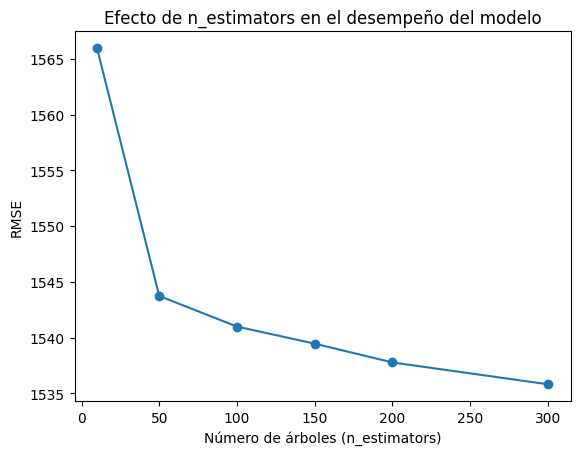

In [18]:
import matplotlib.pyplot as plt

estimator_range = [10, 50, 100, 150, 200, 300]
rmse_scores = []

for n in estimator_range:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_features='sqrt',
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores.append(np.sqrt(-scores).mean())

# Gráfica
plt.figure()
plt.plot(estimator_range, rmse_scores, marker='o')
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("RMSE")
plt.title("Efecto de n_estimators en el desempeño del modelo")
plt.show()

Después de probar diferentes combinaciones de parámetros, el mejor modelo de Random Forest se obtuvo con max_depth = 10, max_features = 'sqrt' y n_estimators = 200.

Con esta configuración, el modelo logró un RMSE de 1564.25, lo que significa que en promedio se equivoca en alrededor de 1564 unidades al hacer predicciones. Además, el R² fue de 0.84, lo cual indica que el modelo logra explicar aproximadamente el 84% de la variabilidad de los datos. En general, estos resultados muestran que el modelo tiene un buen desempeño.

Sobre los parámetros:

El max_depth = 10 ayudó a que los árboles no sean demasiado complejos. Si fueran más profundos podrían sobreajustar, pero así se logra un buen equilibrio.
El max_features = 'sqrt' hace que en cada división se usen menos variables, lo que ayuda a que los árboles sean diferentes entre sí y mejora la generalización.
El n_estimators = 200 permite tener más árboles en el modelo, lo que hace que las predicciones sean más estables y reduce el error.

En conclusión, ajustar estos parámetros permitió mejorar el modelo y obtener un buen balance entre precisión y capacidad de generalizar a nuevos datos.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [20]:
# Celda 6
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Creamos el modelo de XGBoost para regresión
xgb_model = XGBRegressor(
    n_estimators=200,     # número de árboles
    learning_rate=0.1,    # tasa de aprendizaje
    max_depth=5,          # profundidad de cada árbol
    random_state=42,
    n_jobs=-1
)

# Entrenamos el modelo
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("RMSE XGBoost:", rmse_xgb)
print("MAE XGBoost:", mae_xgb)
print("R² XGBoost:", r2_xgb)

RMSE XGBoost: 1562.5048481592773
MAE XGBoost: 1142.6629300370778
R² XGBoost: 0.8403897665212194


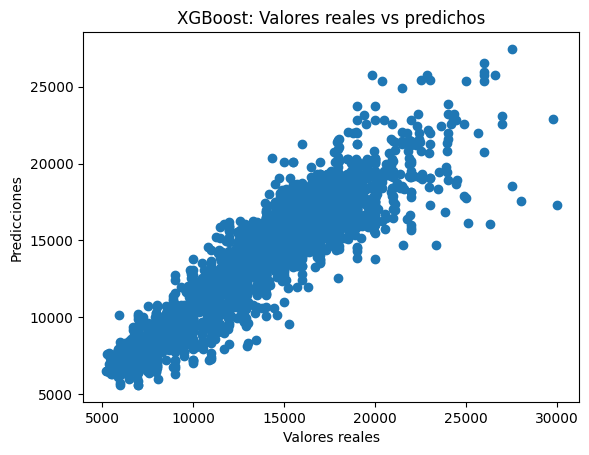

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("XGBoost: Valores reales vs predichos")
plt.show()

El modelo XGBoost obtuvo un buen desempeño, con un RMSE de 1562.50 y un MAE de 1142.66, lo que indica que el error de predicción es relativamente bajo. Además, el R² de 0.84 muestra que el modelo logra explicar aproximadamente el 84% de la variabilidad de los datos.

En general, el modelo presenta una buena capacidad predictiva y resultados muy similares a los obtenidos con Random Forest, lo que indica que ambos modelos son adecuados para este problema.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [22]:
# Celda 7
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Modelo base
xgb = XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Grilla de parámetros
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'gamma': [0, 1, 5],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Entrenamiento
grid_search.fit(X_train, y_train)

# Mejores parámetros
best_xgb = grid_search.best_estimator_
print("Mejores parámetros:", grid_search.best_params_)

# Evaluación final
y_pred_best = best_xgb.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("RMSE mejor modelo:", rmse_best)
print("R² mejor modelo:", r2_best)

Mejores parámetros: {'colsample_bytree': 0.5, 'gamma': 1, 'learning_rate': 0.1}
RMSE mejor modelo: 1553.1266418973803
R² mejor modelo: 0.8422999885572213


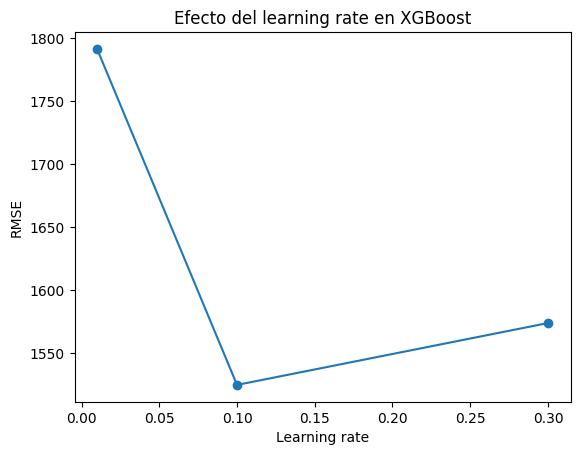

In [23]:
lr_range = [0.01, 0.1, 0.3]
rmse_scores = []

for lr in lr_range:
    xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=lr,
        gamma=1,
        colsample_bytree=0.5,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores.append(np.sqrt(-scores).mean())

# Gráfica
plt.figure()
plt.plot(lr_range, rmse_scores, marker='o')
plt.xlabel("Learning rate")
plt.ylabel("RMSE")
plt.title("Efecto del learning rate en XGBoost")
plt.show()

Después de calibrar los parámetros del modelo XGBoost, se obtuvo como mejor combinación colsample_bytree = 0.5, gamma = 1 y learning_rate = 0.1. Con estos valores, el modelo logró un RMSE de 1553.13 y un R² de 0.84, lo que indica un buen desempeño.

Se observa una ligera mejora respecto al modelo anterior, ya que el error disminuyó y la capacidad explicativa aumentó. Esto sugiere que ajustar los parámetros permitió que el modelo generalice mejor y capture de forma más adecuada los patrones de los datos.

En general, el modelo calibrado presenta un buen equilibrio entre precisión y complejidad, siendo adecuado para realizar predicciones en este problema.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [31]:
# Celda 8
results = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost'],
    'RMSE': [rmse_rf, rmse_xgb],
    'MAE': [mae_rf, mae_xgb],
    'R2': [r2_rf, r2_xgb]
},index=['RMSE','MAE'])
print(results)

             Modelo         RMSE          MAE        R2
RMSE  Random Forest  1791.218597  1336.613959  0.790244
MAE         XGBoost  1562.504848  1142.662930  0.840390


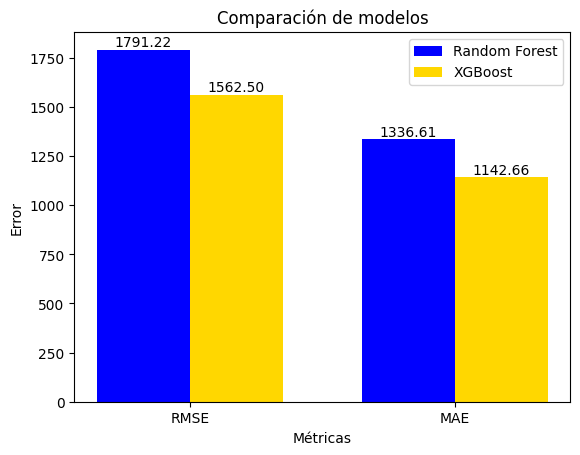

In [36]:
metrics = ['RMSE', 'MAE']
rf_values = [rmse_rf, mae_rf]
xgb_values = [rmse_xgb, mae_xgb]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()

bars1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='blue')
bars2 = ax.bar(x + width/2, xgb_values, width, label='XGBoost', color='gold')

ax.set_xlabel('Métricas')
ax.set_ylabel('Error')
ax.set_title('Comparación de modelos')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:.2f}',
                ha='center', va='bottom')

plt.show()

En la gráfica se comparan los modelos Random Forest y XGBoost utilizando las métricas RMSE y MAE. Se observa que XGBoost presenta un mejor desempeño en ambas métricas, ya que obtiene valores más bajos de error, lo que indica que sus predicciones son más precisas.

Sin embargo, también se puede notar que la diferencia entre ambos modelos no es muy grande, por lo que Random Forest sigue siendo una alternativa competitiva. En particular, la diferencia en el MAE es relativamente pequeña en proporción al error total, lo que sugiere que ambos modelos tienen un comportamiento similar en términos de precisión.

Una posible razón del mejor desempeño de XGBoost es su capacidad de regularización, lo que le permite controlar el sobreajuste y generalizar mejor a nuevos datos. Además, XGBoost utiliza un enfoque de boosting, donde los árboles se construyen de manera secuencial corrigiendo los errores anteriores, lo que le permite capturar patrones más complejos.

Por otro lado, aunque Random Forest también es un modelo robusto y capaz de manejar relaciones no lineales, los árboles se construyen de manera independiente, por lo que no aprende de los errores previos, lo que puede limitar ligeramente su desempeño en comparación con XGBoost.

En conclusión, **XGBoost** se puede considerar el **mejor modelo** en este caso, aunque la diferencia no es muy amplia, lo que indica que ambos modelos son adecuados para el problema.